In [2]:
import torch
import models as m
import os
import json
import matplotlib.pyplot as plt
import torch.distributions as dist
import numpy as np
import math
import shutil
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


In [3]:
torch.set_default_dtype(torch.float32)

if torch.cuda.is_available(): 
    device = torch.device('cuda:0')
    dtype = torch.FloatTensor
elif torch.mps.is_available():
    device = torch.device('mps')
    dtype = torch.FloatTensor
else:
    device = torch.device('cpu')
    dtype = torch.FloatTensor
    
def t(x):
    # j'avais des problèmes de type avec les long 
    return torch.as_tensor(x, dtype=torch.get_default_dtype()).to(device)

print(device)


cuda:0


In [4]:
BASE_PATH = os.getcwd()
RUNS_ROOT = os.path.join(BASE_PATH, "runs")
EXP_NAME = "comparaison"
EXP_DIR = os.path.join(RUNS_ROOT, EXP_NAME)
RUN_ID = '002'
RUN_DIR = os.path.join(EXP_DIR, RUN_ID)  
WEIGHTS_DIR = os.path.join(RUN_DIR, "weights")
LOGS_DIR = os.path.join(RUN_DIR, "logs")
VIDEO_DIR = os.path.join(RUN_DIR, 'videos')

with open(os.path.join(LOGS_DIR, 'hparams.json')) as json_data:
    hparams = json.load(json_data)
    json_data.close()
   
hparams

{'batch_size': 32,
 'N_epoch': 60,
 'EVAL_EVERY': 100,
 'lr': 0.0001,
 'grad_clip': 1.0,
 'img_size': 64,
 'sigma': {'schedule': 'log',
  'min': 0.01,
  'max': 50.0,
  'n_sigmas': 1000,
  'values': [50.00000762939453,
   49.57553482055664,
   49.1546630859375,
   48.73736572265625,
   48.323612213134766,
   47.913368225097656,
   47.50661087036133,
   47.103302001953125,
   46.70342254638672,
   46.30693435668945,
   45.91381072998047,
   45.52402877807617,
   45.13755416870117,
   44.754356384277344,
   44.37441635131836,
   43.99769973754883,
   43.624183654785156,
   43.25383758544922,
   42.886634826660156,
   42.52254867553711,
   42.161556243896484,
   41.803627014160156,
   41.448734283447266,
   41.09685516357422,
   40.74796676635742,
   40.40203857421875,
   40.059043884277344,
   39.718963623046875,
   39.381771087646484,
   39.04743957519531,
   38.715946197509766,
   38.38726806640625,
   38.06138229370117,
   37.73826217651367,
   37.41788101196289,
   37.100223541259766,

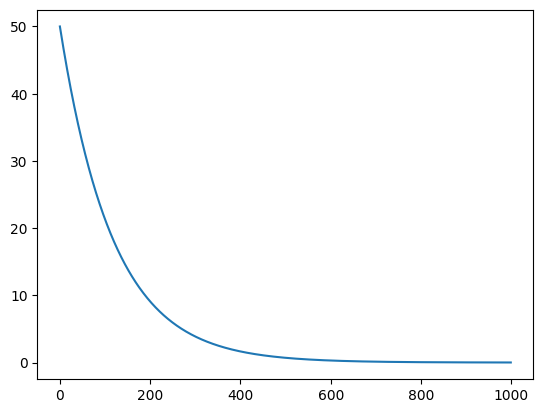

In [5]:
SIGMAS = t(hparams['sigma']['values'])
plt.plot(SIGMAS.cpu())

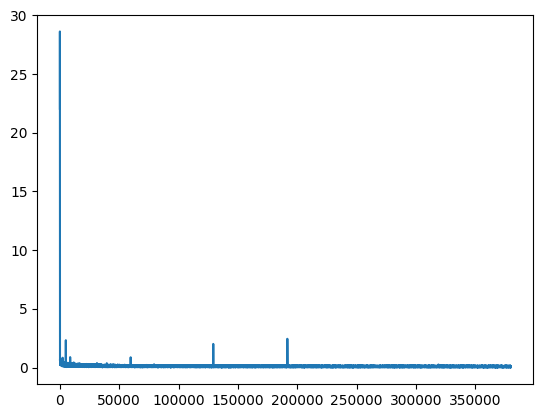

In [6]:
Loss = np.load(os.path.join(LOGS_DIR,'train_loss.npy'))
steps_eval = np.load(os.path.join(LOGS_DIR,'steps_eval.npy'))
plt.plot(Loss)
plt.show()
# loss_sigma = np.load(os.path.join(LOGS_DIR,"train_loss_per_sigma.npy"))   # (n_eval, n_sigmas)
# sigmas = np.load(os.path.join(LOGS_DIR,"sigmas.npy"))                    # (n_sigmas,)

# for i in range(sigmas.shape[0]):
#     plt.plot(loss_sigma.T[i],label= f'{sigmas[i]:.3f}')
#     plt.legend()
# plt.show()
# plt.plot(loss_sigma[0])
# plt.xticks(range(len(sigmas)), np.round(sigmas,3))
# plt.title("Loss par sigma (dernier eval)")
# plt.show()


In [7]:
w = torch.load(os.path.join(WEIGHTS_DIR, 'model.pt'),map_location=device,weights_only=True)
model = m.SmallUNetSigma(
    in_ch=hparams['model']['in_channel'],
    base_ch=hparams['model']['base_ch'],
    channel_mults=hparams['model']['channel_mults'],  
    emb_dim=hparams['model']['sigma_emb_dim'],
).to(device)

model.load_state_dict(w)
model = model.to(device)

total = sum(p.numel() for p in model.parameters())
print(f"{total/1e6:.2f} M params")

model.eval()

12.16 M params


SmallUNetSigma(
  (sigma_emb): SigmaEmbedding(
    (net): Sequential(
      (0): Linear(in_features=1, out_features=16, bias=True)
      (1): SiLU()
      (2): Linear(in_features=16, out_features=16, bias=True)
      (3): SiLU()
    )
  )
  (init_conv): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down_blocks): ModuleList(
    (0-1): 2 x ResBlock(
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act1): SiLU()
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act2): SiLU()
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (emb_proj1): Sequential(
        (0): SiLU()
        (1): Linear(in_features=16, out_features=64, bias=True)
      )
      (emb_proj2): Sequential(
        (0): SiLU()
        (1): Linear(in_features=16, out_features=64, bias=True)
      )
      (skip): Identity()
    )
    (2): ResBlock(
      (norm1): 

In [8]:
# Compute Score Norm 
transform = transforms.Compose([
    transforms.CenterCrop(178),          # CelebA original size/crop
    transforms.Resize(hparams['img_size']),              # or 64/256 etc.
    transforms.ToTensor(),               # [0,1]
    transforms.Lambda(lambda x: x * 2 - 1)  # [-1,1]
])


full_data = datasets.ImageFolder(
    root="data/celeba",
    transform=transform,
)

print("Nb d'images :", len(full_data))
print("Classes :", full_data.classes)


Nb d'images : 202599
Classes : ['img_align_celeba']


Feature batch shape: torch.Size([1, 3, 64, 64])
Labels batch shape: torch.Size([1])
tensor(-0.9608) tensor(0.8431)


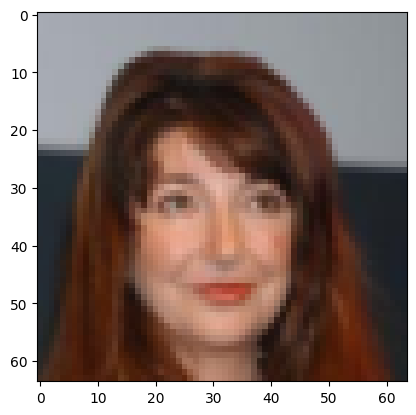

Label: 0


In [9]:

dataloader = DataLoader(full_data,batch_size=1,shuffle=True)
train_features, train_labels = next(iter(dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")

img = train_features[0].squeeze()
print(img.min(),img.max())
label = train_labels[0]
plt.imshow(((img + 1)/2).permute(1, 2, 0))
plt.show()
print(f"Label: {label}")

In [10]:
COMPUTE_SCORE_NORM = True
if COMPUTE_SCORE_NORM : 
    if not os.path.exists(os.path.join(LOGS_DIR,"SCORE_NORM.npy")) : 
        
        NUM_BATCH = 20
        N_mean = []
        N_var  = []

        data_iter = iter(dataloader)

        model.eval()  # pas obligatoire mais propre

        with torch.no_grad():  
            for idx in range(hparams['sigma']['n_sigmas']):
                s = SIGMAS[idx]

                # online mean/var (Welford)
                count = 0
                mean = 0.0
                M2 = 0.0

                for _ in range(NUM_BATCH):

                    try:
                        x, _ = next(data_iter)
                    except StopIteration:
                        data_iter = iter(dataloader)
                        x, _ = next(data_iter)

                    x = x.to(device)
                    B = x.size(0)

                    sigma = s.expand(B, 1)
                    while sigma.dim() < x.dim():
                        sigma = sigma.unsqueeze(-1)

                    eps = torch.randn_like(x)
                    x_noisy = x + sigma * eps

                    score = model(x_noisy, sigma)

                    score_sq_batch = (score ** 2).view(B, -1).sum(dim=1)

                    # unbatch + update mean/var
                    for val in score_sq_batch.detach().cpu().tolist():
                        count += 1
                        delta = val - mean
                        mean += delta / count
                        delta2 = val - mean
                        M2 += delta * delta2

                var = M2 / (count - 1) if count > 1 else 0.0

                N_mean.append(mean)
                N_var.append(var)

        SCORE_NORM = torch.tensor(N_mean, device=device)
        SCORE_NORM_VAR = torch.tensor(N_var, device=device)

        print("SCORE_NORM (mean):", SCORE_NORM)
        print("SCORE_NORM_VAR:", SCORE_NORM_VAR)

        CV = torch.sqrt(SCORE_NORM_VAR)/ SCORE_NORM

        print("CV", CV)
        np.save(os.path.join(LOGS_DIR,"SCORE_NORM.npy"),SCORE_NORM.cpu())
    else : 
        SCORE_NORM = np.load(os.path.join(LOGS_DIR,"SCORE_NORM.npy"))

In [11]:
# pas de gradient ici pour ALD 
def make_score_from_model(model, sigma_scalar,eps_loss = False):
    sigma_scalar = float(sigma_scalar)
    
    @torch.no_grad()
    def score(x):
        # x: (B, x_dim)
        B = x.shape[0]
        sigma = x.new_full((B, 1), sigma_scalar).to(device)   # (B,1) 
        return model(x, sigma)
     
    return score

In [12]:
estimated_distribution_scores = [make_score_from_model(model,noise) for noise in list(SIGMAS)]

In [13]:
sigma_prior = SIGMAS.max().item()  # ou sigmas.max().item()
prior_normal = dist.Normal(
    loc=torch.tensor(0.0, device=device),
    scale=torch.tensor(sigma_prior, device=device),
)
prior_unif = dist.Uniform(-1,1)


In [14]:
u = []
for x in range(5):
    v,_ = next(iter(dataloader))
    u.append(v)
        
z = torch.concat(u).to(device)

for i in range(z.shape[0]) : 
    plt.subplot(1,z.shape[0],i+1)
    img = z[i].clone().squeeze().permute(1,2,0).detach().cpu()
    img_norm = (img - img.min()) / (img.max() -img.min())
    plt.imshow(img_norm)
    plt.axis('off')

KeyboardInterrupt: 

In [14]:
if COMPUTE_SCORE_NORM : 
    def annealded_langevin_sampler_snr(prior, noisy_distrib_scores, noise_factor,
                                    SNR, norm, T, n_chain, save_dir=None):
        
        
        u = []
        for x in range(n_chain):
            v,_ = next(iter(dataloader))
            u.append(v)
            
        z = torch.concat(u).to(device)
        # z is to strat from real images
        C = 3
        H = hparams['img_size']
        W = hparams['img_size']
        X =  prior.sample((n_chain, C, H, W)).to(device)

        D = H * W
        PLOT_STEP_EVERY = np.inf         
        IDX_TO_TRACK = [u for u in range(n_chain)]              # on suit l'image X[0] dans le temps

        if save_dir is not None:
            if os.path.exists(save_dir):
                shutil.rmtree(save_dir)   # supprime tout le dossier et ce qu'il y a dedans
            os.makedirs(save_dir)

        frame = 0  

        for i in range(len(noisy_distrib_scores)):
            tau = 2 * D * SNR / norm[i]
            noise_std = math.sqrt(2 * tau)   # niveau de bruit

            for step in range(T):

                X = X + tau * noisy_distrib_scores[i](X) + noise_std * torch.randn_like(X)

                
                if ((step + 1) % T == 0 ) or ((step +1) % PLOT_STEP_EVERY == 0) or step == 0 :
                    plt.figure(figsize=(3*len(IDX_TO_TRACK), 3*len(IDX_TO_TRACK)))
                    for y,z in enumerate(IDX_TO_TRACK) : 
                        plt.subplot(1,len(IDX_TO_TRACK),y+1)
                        img = X[z].clone().squeeze().permute(1,2,0).detach().cpu()
                        img_norm = (img - img.min()) / (img.max() -img.min())
                        plt.imshow(img_norm)
                        plt.axis('off')
                    plt.title(
                        f"sigma={noise_factor[i]:.3f} | "
                        f"SNR={SNR:.2e} | "
                        f"noise_std={noise_std:.2e} | "
                        f"step={step}"
                    )

                    if save_dir is not None:
                        fname = os.path.join(save_dir, f"frame_{frame:05d}.png")
                        plt.savefig(fname, dpi=150, bbox_inches='tight', pad_inches=0)
                        plt.close()
                    else:
                        plt.show()

                    frame += 1

        for step in range(T):

            X = X + tau * noisy_distrib_scores[i](X) 

        
            if ((step + 1) % T == 0 ) or ((step +1) % PLOT_STEP_EVERY == 0) or step == 0 :
                plt.figure(figsize=(3*len(IDX_TO_TRACK), 3*len(IDX_TO_TRACK)))
                for y,z in enumerate(IDX_TO_TRACK) : 
                    plt.subplot(1,len(IDX_TO_TRACK),y+1)
                    img = X[z].clone().squeeze().permute(1,2,0).detach().cpu()
                    img_norm = (img - img.min()) / (img.max() -img.min())
                    plt.imshow(img_norm)
                    plt.axis('off')
                plt.title(
                    f"sigma={noise_factor[i]:.3f} | "
                    f"SNR={SNR:.2e} | "
                    f"noise_std={noise_std:.2e} | "
                    f"step={step}"
                )

                if save_dir is not None:
                    fname = os.path.join(save_dir, f"frame_{frame:05d}.png")
                    plt.savefig(fname, dpi=150, bbox_inches='tight', pad_inches=0)
                    plt.close()
                else:
                    plt.show()

                frame += 1
        
        if save_dir is not None:
            os.system(f"./make_ald_video.sh {save_dir} {SNR} {T}")

        return X


In [ ]:
for SNR in [0.05]:
    ALD_estimated_score_snr = annealded_langevin_sampler_snr(
        prior_normal,
        estimated_distribution_scores,
        SIGMAS,
        SNR,
        SCORE_NORM,
        T = 2,
        n_chain=2,
        save_dir=None
    )

NameError: name 'annealded_langevin_sampler_snr' is not defined

# IF too much noise level and cannot compute score norm before hand

In [32]:
def annealded_langevin_sampler_snr(prior, noisy_distrib_scores, noise_factor,
                                 SNR, T, n_chain, save_dir=None):
     
    u = []
    for x in range(n_chain):
        v,_ = next(iter(dataloader))
        u.append(v)
        
    z = torch.concat(u).to(device)
    # z is to strat from real images
    C = 3
    H = hparams['img_size']
    W = hparams['img_size']
    X =  prior.sample((n_chain, C, H, W)).to(device)

    D = H * W
    PLOT_STEP_EVERY = np.inf         
    IDX_TO_TRACK = [u for u in range(n_chain)]              # on suit l'image X[0] dans le temps

    if save_dir is not None:
        if os.path.exists(save_dir):
            shutil.rmtree(save_dir)   # supprime tout le dossier et ce qu'il y a dedans
        os.makedirs(save_dir)

    frame = 0  

    for i in range(len(noisy_distrib_scores)):

        with torch.no_grad():
            score_batch = noisy_distrib_scores[i](X)   # (B,C,H,W)
            B = score_batch.shape[0]
            score_norm = torch.norm(
                score_batch.view(B, -1), dim=-1
            ).mean() # norme moyenne sur le batch
        tau = 2 * D * SNR / (score_norm + 1e-12)
        noise_std = math.sqrt(2 * tau)   # niveau de bruit

        for step in range(T):

            X = X + tau * noisy_distrib_scores[i](X) + noise_std * torch.randn_like(X)

            
            if ((step + 1) % T == 0 ) or ((step +1) % PLOT_STEP_EVERY == 0) or step == 0 :
                plt.figure(figsize=(3*len(IDX_TO_TRACK), 3*len(IDX_TO_TRACK)))
                for y,z in enumerate(IDX_TO_TRACK) : 
                    plt.subplot(1,len(IDX_TO_TRACK),y+1)
                    img = X[z].clone().squeeze().permute(1,2,0).detach().cpu()
                    img_norm = (img - img.min()) / (img.max() -img.min())
                    plt.imshow(img_norm)
                    plt.axis('off')
                plt.title(
                    f"sigma={noise_factor[i]:.3f} | "
                    f"SNR={SNR:.2e} | "
                    f"noise_std={noise_std:.2e} | "
                    f"step={step}"
                )

                if save_dir is not None:
                    fname = os.path.join(save_dir, f"frame_{frame:05d}.png")
                    plt.savefig(fname, dpi=150, bbox_inches='tight', pad_inches=0)
                    plt.close()
                else:
                    plt.show()

                frame += 1

    for step in range(T):

        X = X + tau * noisy_distrib_scores[i](X) 

       
        if ((step + 1) % T == 0 ) or ((step +1) % PLOT_STEP_EVERY == 0) or step == 0 :
            plt.figure(figsize=(3*len(IDX_TO_TRACK), 3*len(IDX_TO_TRACK)))
            for y,z in enumerate(IDX_TO_TRACK) : 
                plt.subplot(1,len(IDX_TO_TRACK),y+1)
                img = X[z].clone().squeeze().permute(1,2,0).detach().cpu()
                img_norm = (img - img.min()) / (img.max() -img.min())
                plt.imshow(img_norm)
                plt.axis('off')
            plt.title(
                f"sigma={noise_factor[i]:.3f} | "
                f"SNR={SNR:.2e} | "
                f"noise_std={noise_std:.2e} | "
                f"step={step}"
            )

            if save_dir is not None:
                fname = os.path.join(save_dir, f"frame_{frame:05d}.png")
                plt.savefig(fname, dpi=150, bbox_inches='tight', pad_inches=0)
                plt.close()
            else:
                plt.show()

            frame += 1
    
    if save_dir is not None:
        os.system(f"./make_ald_video.sh {save_dir} {SNR} {T}")

    return X


In [33]:
OUTDIR = os.path.join(VIDEO_DIR,'out/')

In [ ]:
for SNR in [0.04]:
    ALD_estimated_score_snr = annealded_langevin_sampler_snr(
        prior_unif,
        estimated_distribution_scores,
        SIGMAS,
        SNR,
        T = 10,
        n_chain=16,
        save_dir=None
    )